In [1]:
import pandas as pd             # data package
import matplotlib.pyplot as plt # graphics 
import datetime as dt
import numpy as np
from scipy.stats.mstats import gmean

import matplotlib.ticker as mtick 

import requests, io             # internet and input tools  
import zipfile as zf            # zip file tools 
import os  

#import weightedcalcs as wc
#import numpy as np

import pyarrow as pa
import pyarrow.parquet as pq

In [4]:
# The first step is to make the weights. The weights will be off the total imports for 2024.
# So at the product level, that products weight in total imports. 

file = "C:\\github\\median-tariff\\data\\imports-hs10\\TOTALdata-2024-12.parquet"

df = pq.read_table(file).to_pandas()

df["CAL_DUT_MO"] = df["CAL_DUT_MO"].astype(float)

df["CON_VAL_MO"] = df["CON_VAL_MO"].astype(float)

df.time = pd.to_datetime(df.time, format="%Y-%m")

df["applied_tariff"] = df["CAL_DUT_MO"] / df["CON_VAL_MO"]

foo = df.set_index("time").loc["2024"].copy()

totalimports = foo["CON_VAL_MO"].sum()

grp = foo.groupby("I_COMMODITY")

weights = grp["CON_VAL_MO"].sum() / totalimports

In [20]:
country_list = pd.read_csv("C:\\github\\median-tariff\\data\\country-list.csv", header=None, names=["CTY_CODE"])

In [22]:
country_list.head()

,CTY_CODE
0,5700
1,2010
2,1220
3,5880
4,4280


In [5]:
file = "C:\\github\\median-tariff\\data\\imports-hs10\\0003data-2024-12.parquet"

dfcntry = pq.read_table(file).to_pandas()

dfcntry["CAL_DUT_MO"] = dfcntry["CAL_DUT_MO"].astype(float)

dfcntry["CON_VAL_MO"] = dfcntry["CON_VAL_MO"].astype(float)

dfcntry.time = pd.to_datetime(dfcntry.time, format="%Y-%m")

dfcntry["applied_tariff"] = dfcntry["CAL_DUT_MO"] / dfcntry["CON_VAL_MO"]

dfcntry = pd.merge(dfcntry, weights.rename("weights"), how="left", on="I_COMMODITY", indicator=True)

In [24]:
country_list.CTY_CODE.iloc[:]

0     5700
1     2010
2     1220
3     5880
4     4280
5     5800
6     5520
7     5830
8     4190
9     5330
10    4120
11    4759
12    4279
13    4419
14    5570
15    5490
16    3510
17    5590
18    4210
19    5600
20    5081
21    4231
22    5170
23    4700
24    4621
25    3010
26    4330
27    6021
28    4010
29    3370
Name: CTY_CODE, dtype: int64

In [29]:
dfcntry.head()

,CTY_NAME,CON_VAL_MO,CAL_DUT_MO,I_COMMODITY,I_COMMODITY_SDESC,time,COMM_LVL,CTY_CODE,applied_tariff,weights
0,CHILE,2500.0,0.0,0106199120,"DOGS, LIVE",2013-07-01,HS10,3370,0.0,0.000008
1,CHILE,0.0,0.0,0106199120,"DOGS, LIVE",2013-08-01,HS10,3370,NaN,0.000008
2,CHILE,0.0,0.0,0106199120,"DOGS, LIVE",2013-09-01,HS10,3370,NaN,0.000008
3,CHILE,0.0,0.0,0106199120,"DOGS, LIVE",2013-10-01,HS10,3370,NaN,0.000008
4,CHILE,0.0,0.0,0106199120,"DOGS, LIVE",2013-11-01,HS10,3370,NaN,0.000008


In [31]:
# Loop through all countries and calculate tariff metrics
all_results = []

for country in country_list.CTY_CODE.iloc[:]:  # Assuming country codes are in first column
    
    file = f"C:\\github\\median-tariff\\data\\imports-hs10\\{country}data-2024-12.parquet"
    
    # Load country data
    dfcntry = pq.read_table(file).to_pandas()
    
    dfcntry["CAL_DUT_MO"] = dfcntry["CAL_DUT_MO"].astype(float)
    dfcntry["CON_VAL_MO"] = dfcntry["CON_VAL_MO"].astype(float)
    dfcntry.time = pd.to_datetime(dfcntry.time, format="%Y-%m")
    dfcntry["applied_tariff"] = dfcntry["CAL_DUT_MO"] / dfcntry["CON_VAL_MO"]
    
    # Merge with weights
    dfcntry = pd.merge(dfcntry, weights.rename("weights"), how="left", on="I_COMMODITY")
    
    # Calculate metrics
    results_df = calculate_tariff_metrics(dfcntry)
    
    # Add to list
    all_results.append(results_df)
    
    print(f"Processed {country}: {results_df['CTY_NAME'].iloc[0]}")

# Combine all results into one dataframe
combined_results = pd.concat(all_results)
combined_results

Processed 5700: CHINA
Processed 2010: MEXICO
Processed 2010: MEXICO
Processed 1220: CANADA
Processed 1220: CANADA
Processed 5880: JAPAN
Processed 5880: JAPAN
Processed 4280: GERMANY
Processed 4280: GERMANY
Processed 5800: KOREA, SOUTH
Processed 5800: KOREA, SOUTH
Processed 5520: VIETNAM
Processed 5520: VIETNAM
Processed 5830: TAIWAN
Processed 5830: TAIWAN
Processed 4190: IRELAND
Processed 4190: IRELAND
Processed 5330: INDIA
Processed 5330: INDIA
Processed 4120: UNITED KINGDOM
Processed 4120: UNITED KINGDOM
Processed 4759: ITALY
Processed 4759: ITALY
Processed 4279: FRANCE
Processed 4279: FRANCE
Processed 4419: SWITZERLAND
Processed 4419: SWITZERLAND
Processed 5570: MALAYSIA
Processed 5570: MALAYSIA
Processed 5490: THAILAND
Processed 5490: THAILAND
Processed 3510: BRAZIL
Processed 3510: BRAZIL
Processed 5590: SINGAPORE
Processed 5590: SINGAPORE
Processed 4210: NETHERLANDS
Processed 4210: NETHERLANDS
Processed 5600: INDONESIA
Processed 5600: INDONESIA
Processed 5081: ISRAEL
Processed 508

,CTY_NAME,mean_weighted,square_weighted,median,simple_tariff
time,,,,,
2013-01-01,CHINA,0.010770,0.034659,0.030900,0.031381
2013-02-01,CHINA,0.010595,0.034266,0.030999,0.033194
2013-03-01,CHINA,0.010660,0.034238,0.030028,0.026393
2013-04-01,CHINA,0.010744,0.034602,0.030007,0.028836
2013-05-01,CHINA,0.010660,0.034250,0.030015,0.028581
...,...,...,...,...,...
2025-04-01,CHILE,0.006709,0.035062,0.000071,0.008969
2025-05-01,CHILE,0.010226,0.041595,0.099898,0.031434
2025-06-01,CHILE,0.012476,0.051357,0.100000,0.034234


In [32]:
# Example: View results for a specific country

combined_results.loc["2025-08"]

,CTY_NAME,mean_weighted,square_weighted,median,simple_tariff
time,,,,,
2025-08-01,CHINA,0.331490,0.425932,0.549996,0.397229
2025-08-01,MEXICO,0.041636,0.094555,0.000049,0.046996
2025-08-01,CANADA,0.061802,0.118459,0.000000,0.038438
2025-08-01,JAPAN,0.095148,0.151698,0.148909,0.169153
2025-08-01,GERMANY,0.089747,0.141524,0.138559,0.133076
2025-08-01,"KOREA, SOUTH",0.072439,0.126978,0.111233,0.133501
2025-08-01,VIETNAM,0.066616,0.121608,0.160134,0.099913
2025-08-01,TAIWAN,0.076499,0.134188,0.153771,0.035205
2025-08-01,IRELAND,0.028371,0.085163,0.133333,0.016025


In [30]:
# Automate calculation for all dates
def calculate_tariff_metrics(dfcntry):
    """
    Calculate various tariff metrics over time for a country dataframe.
    
    Parameters:
    -----------
    dfcntry : pandas.DataFrame
        DataFrame containing time series tariff data with columns:
        - time: datetime index
        - applied_tariff: tariff rates
        - weights: product weights
    weights_sum : float
        Sum of weights to use in calculations
    
    Returns:
    --------
    pandas.DataFrame
        DataFrame indexed by time with columns:
        - weights_sum
        - mean_weighted
        - square_weighted
        - median
    """
    results = []

    weights_sum = dfcntry["weights"].sum()
    
    for date in dfcntry['time'].unique():

        bar = dfcntry.set_index("time").loc[date].copy()
        
        meanweighted = (bar["applied_tariff"] * bar["weights"]).sum()
        
        squareweighted = ((bar["applied_tariff"]**2 * bar["weights"]).sum())**0.5
        
        mediantariff = bar["applied_tariff"].median()

        simpletariff = bar['CAL_DUT_MO'].sum() / bar['CON_VAL_MO'].sum()
        
        results.append({
            'time': date,
            'CTY_NAME': bar['CTY_NAME'].iloc[0],
            'mean_weighted': meanweighted,
            'square_weighted': squareweighted,
            'median': mediantariff,
            'simple_tariff': simpletariff
        })
    
    # Convert to DataFrame for easy viewing
    results_df = pd.DataFrame(results).set_index('time').sort_index()
    
    return results_df

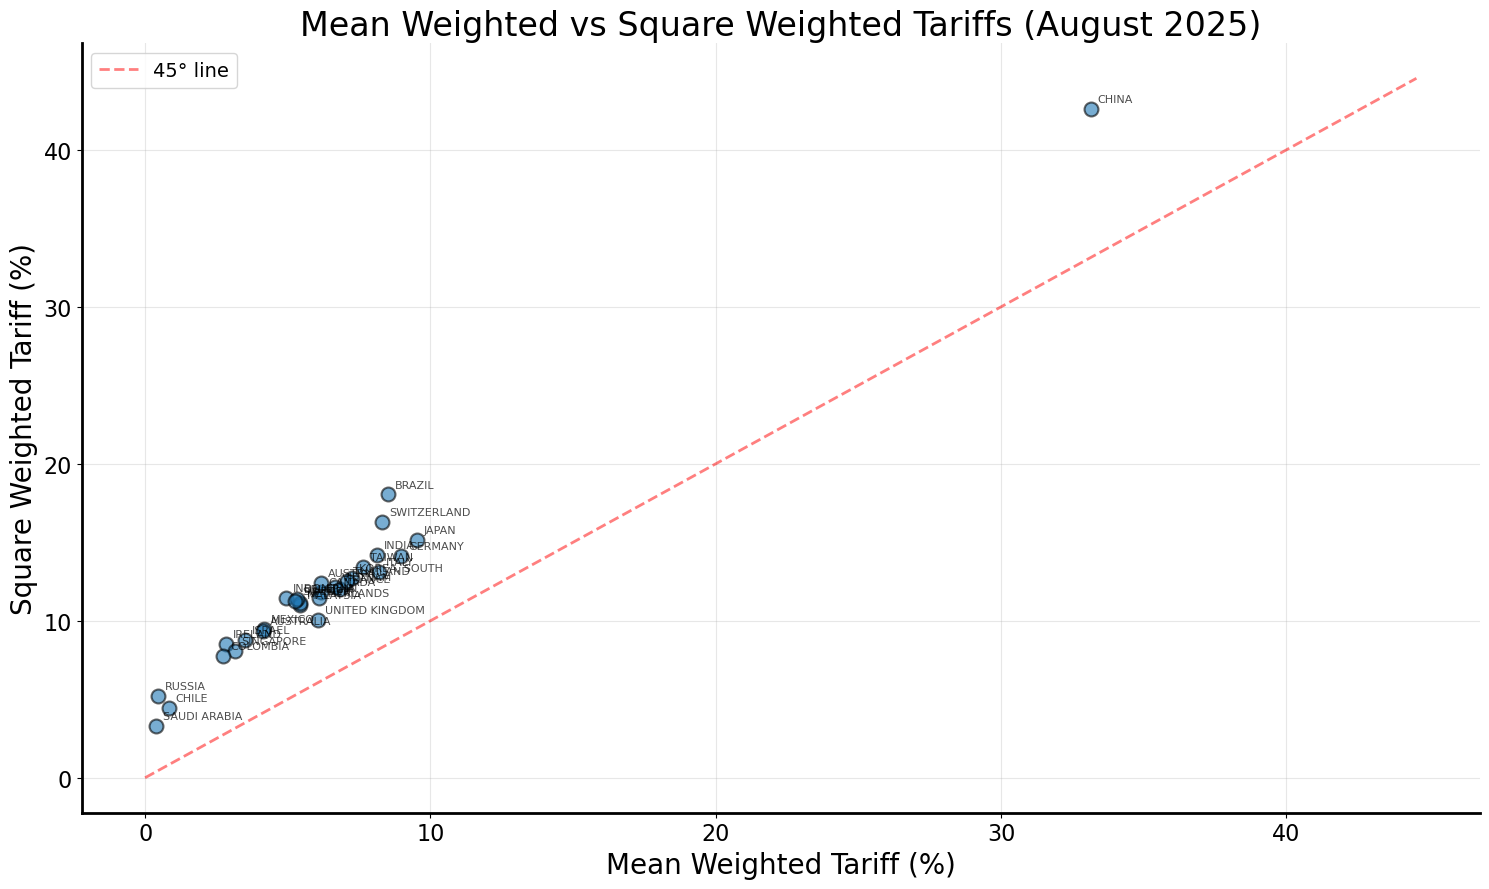

In [33]:
# Scatter plot of mean_weighted vs square_weighted tariffs
fig, ax = plt.subplots(figsize=(15, 9))

# Get August 2025 data for scatter plot
aug_2025 = combined_results.loc["2025-08"]

ax.scatter(100*aug_2025["mean_weighted"], 100*aug_2025["square_weighted"], 
           s=100, alpha=0.6, edgecolors='black', linewidth=1.5)

# Add country labels to points
for idx, row in aug_2025.iterrows():
    ax.annotate(row['CTY_NAME'], 
                xy=(100*row["mean_weighted"], 100*row["square_weighted"]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, alpha=0.7)

# Add 45-degree line for reference
max_val = max(ax.get_xlim()[1], ax.get_ylim()[1])
ax.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, linewidth=2, label='45° line')

ax.set_xlabel("Mean Weighted Tariff (%)", fontsize=20)
ax.set_ylabel("Square Weighted Tariff (%)", fontsize=20)
ax.set_title("Mean Weighted vs Square Weighted Tariffs (August 2025)", fontsize=24)

ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

ax.legend(fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

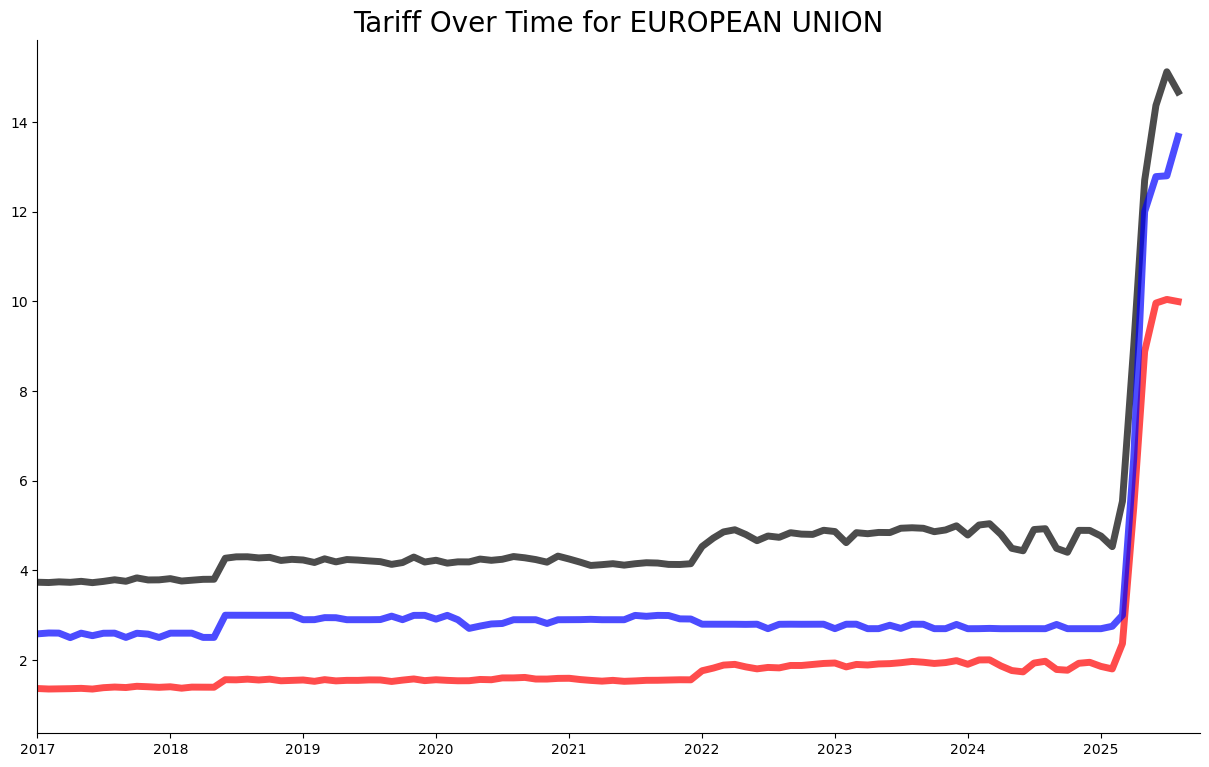

In [170]:
fig, ax = plt.subplots(figsize = (15,9))

ax.plot(results_df.index, 100*results_df["mean_weighted"], color = "red", alpha = 0.7, linewidth = 5)

ax.plot(results_df.index, 100*results_df["square_weighted"], color = "black", alpha = 0.7, linewidth = 5)

ax.plot(results_df.index, 100*results_df["median"], color = "blue", alpha = 0.7, linewidth = 5)

ax.set_title("Tariff Over Time for " + dfcntry["CTY_NAME"].iloc[0], fontsize = 20)

ax.set_xlim([dt.datetime(2017,1,1), dt.datetime(2025,9,30)])

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

plt.show()

In [143]:
grp = dfcntry.groupby("time")

meantariff = grp["applied_tariff"].mean()

mediantariff = grp["applied_tariff"].median()

trimmedmediantariff = grp["applied_tariff"].apply(trimmed_median)

tradeweighttariff = grp.apply(lambda x: x["CAL_DUT_MO"].sum() / x["CON_VAL_MO"].sum(), include_groups=False)

mode_tariff = grp['applied_tariff'].apply(lambda x: x.mode()[0] if len(x.mode()) > 0 else np.nan)

In [144]:
datetolookat = "2025-08"

print(meantariff.loc[datetolookat])

print(mediantariff.loc[datetolookat])

print(trimmedmediantariff.loc[datetolookat])

print(tradeweighttariff.loc[datetolookat])

print(mode_tariff.loc[datetolookat])

time
2025-08-01    0.19149
Name: applied_tariff, dtype: float64
time
2025-08-01    0.155258
Name: applied_tariff, dtype: float64
time
2025-08-01    0.149952
Name: applied_tariff, dtype: float64
time
2025-08-01    0.10552
dtype: float64
time
2025-08-01    0.0
Name: applied_tariff, dtype: float64


In [ ]:
def trimmed_median(x, lower_pct=0.05, upper_pct=0.95):
    """Remove bottom and top percentiles, then compute median"""
    lower_bound = x.quantile(lower_pct)
    upper_bound = x.quantile(upper_pct)
    trimmed = x[(x >= lower_bound) & (x <= upper_bound)]
    
    return trimmed.median() if len(trimmed) > 0 else np.nan



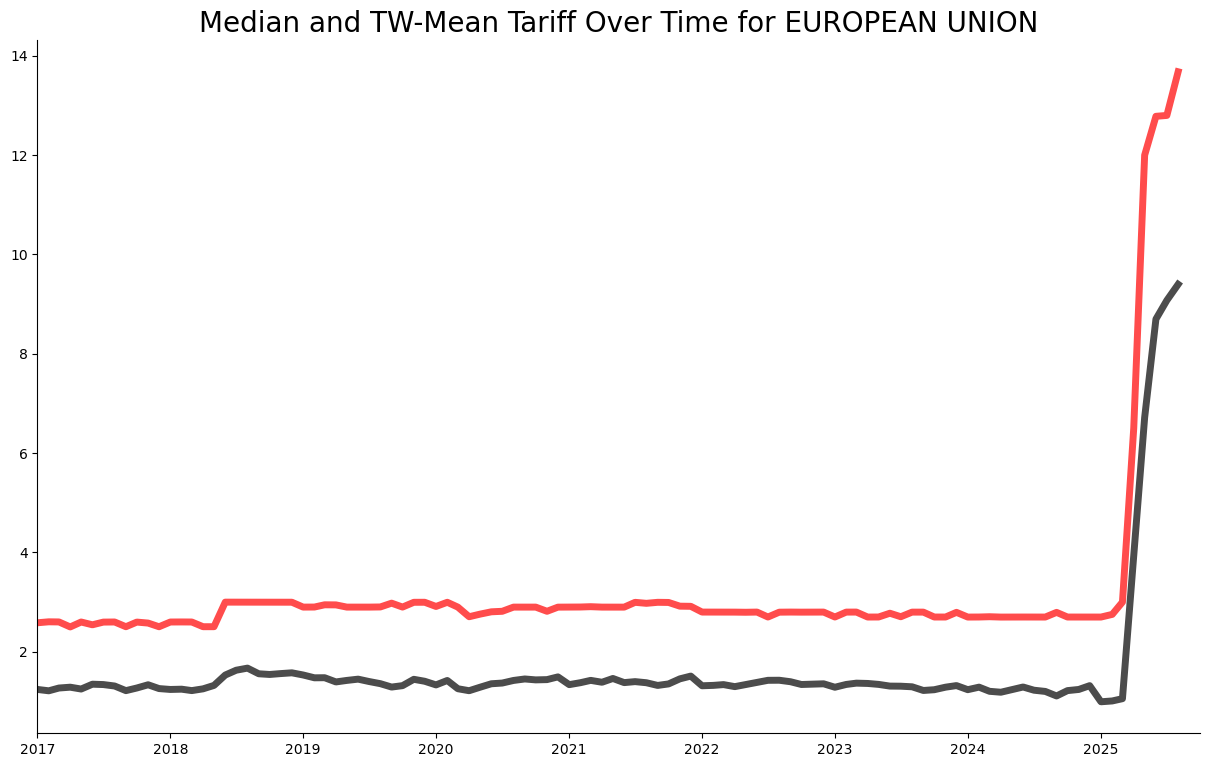

In [71]:
fig, ax = plt.subplots(figsize = (15,9))

ax.plot(mediantariff.index, 100*mediantariff.values, color = "red", alpha = 0.7, linewidth = 5)

ax.plot(tradeweighttariff.index, 100*tradeweighttariff.values, color = "black", alpha = 0.7, linewidth = 5)

ax.set_title("Median and TW-Mean Tariff Over Time for " + df["CTY_NAME"].iloc[0], fontsize = 20)

ax.set_xlim([dt.datetime(2017,1,1), dt.datetime(2025,9,30)])

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

plt.show()

In [2]:
my_key = "&key=34e40301bda77077e24c859c6c6c0b721ad73fc7"
# This is my key. I'm nice and I have it posted. If you will be doing more with this
# please get your own key!

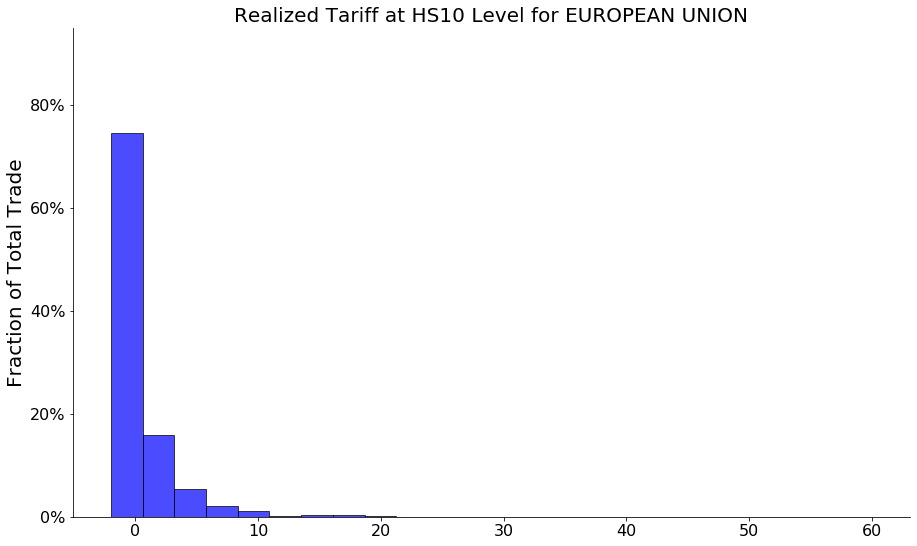

In [53]:
fig, ax = plt.subplots(figsize = (15,9))

bin_edges = np.linspace(-2, 60, 25)  # 50 bins

# Digitize delta_tariff into bins
bin_indices = np.digitize(df["applied_tariff"], bin_edges) - 1

# Sum CON_VAL_MAY in each bin
bin_sums = np.zeros(len(bin_edges) - 1)
for i in range(len(bin_sums)):
    bin_sums[i] = df.loc[bin_indices == i, "CON_VAL_MO"].sum()

# Convert to fraction of total CON_VAL_MAY
fractions = bin_sums / df["CON_VAL_MO"].sum()

ax.bar(bin_edges[:-1], fractions, width=np.diff(bin_edges), align='edge', color='blue', alpha=0.7, edgecolor='black')

ax.set_ylim(top=0.95)

ax.set_ylabel("Fraction of Total Trade", fontsize = 20)

# ax.set_xlabel("Change in HS10 Tariff: May 2025 - May 2024", fontsize = 20)

ax.set_title("Realized Tariff at HS10 Level for " + df["CTY_NAME"].iloc[0], fontsize = 20)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

ax.tick_params(axis='x', labelsize=16)  # Change font size of x-axis tick labels
ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

plt.show()

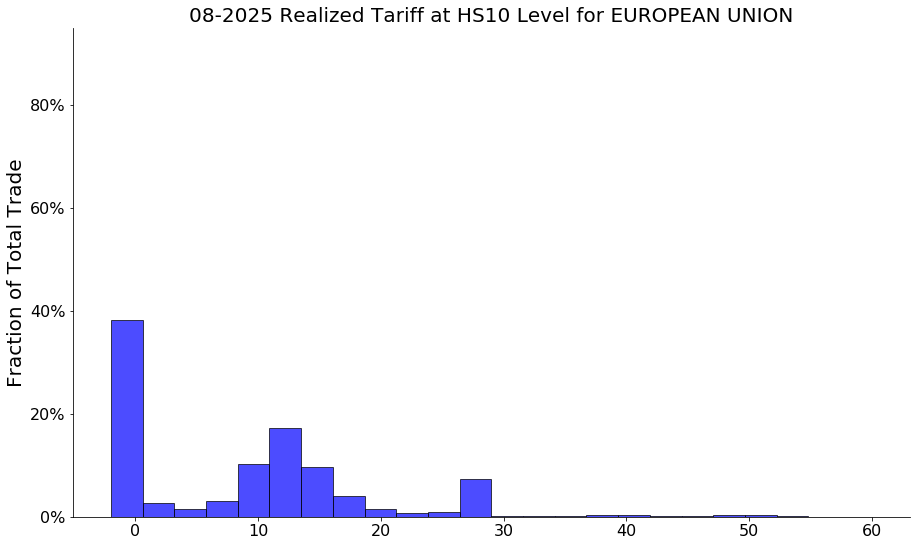

In [ ]:
fig, ax = plt.subplots(figsize = (15,9))

bin_edges = np.linspace(-2, 60, 25)  # 50 bins

# Digitize delta_tariff into bins
bin_indices = np.digitize(df["applied_tariff"], bin_edges) - 1

# Sum CON_VAL_MAY in each bin
bin_sums = np.zeros(len(bin_edges) - 1)
for i in range(len(bin_sums)):
    bin_sums[i] = df.loc[bin_indices == i, "CON_VAL_MO"].sum()

# Convert to fraction of total CON_VAL_MAY
fractions = bin_sums / df["CON_VAL_MO"].sum()

ax.bar(bin_edges[:-1], fractions, width=np.diff(bin_edges), align='edge', color='blue', alpha=0.7, edgecolor='black')

ax.set_ylim(top=0.95)

ax.set_ylabel("Fraction of Total Trade", fontsize = 20)

# ax.set_xlabel("Change in HS10 Tariff: May 2025 - May 2024", fontsize = 20)

ax.set_title("08-2025 Realized Tariff at HS10 Level for " + df["CTY_NAME"].iloc[0], fontsize = 20)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

ax.tick_params(axis='x', labelsize=16)  # Change font size of x-axis tick labels
ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

plt.show()

In [75]:
foo = df[df["HS2"]  == "30"]

foo[foo["delta_predic_tariff"] > 0.0].sort_values("I_COMMODITY")

,I_COMMODITY,applied_tariff,tariff,CON_VAL_MO,I_COMMODITY_SDESC,time,CTY_NAME,HS2,applied_tariff_2024,CON_VAL_2024,delta_applied_tariff,delta_predic_tariff
11308,3001900150,0.000000,10.0,146873.0,"OTHER GLANDS AND ORGANS, DRIED ETC",2025-05-01,EUROPEAN UNION,30,0.000000,556463.0,0.000000,10.0
11309,3001900190,0.006386,10.0,10006357.0,HEPARIN AND ITS SALTS; OTHER HUMAN OR ANIMAL S...,2025-05-01,EUROPEAN UNION,30,0.000000,7538138.0,0.006386,10.0
11310,3002120010,0.000000,10.0,3131608.0,HUMAN BLOOD PLASMA,2025-05-01,EUROPEAN UNION,30,0.000000,24498654.0,0.000000,10.0
2100,3002120020,0.131807,10.0,1590966.0,"NORMAL HUMAN BLOOD SERA, INCLUDING FREEZE-DRIED",2025-05-01,EUROPEAN UNION,30,0.000000,1281644.0,0.131807,10.0
11311,3002120030,0.000000,10.0,404514.0,HUMAN IMMUNE BLOOD SERA,2025-05-01,EUROPEAN UNION,30,0.000000,188635.0,0.000000,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2444,3006100100,8.779141,10.0,37163829.0,"STERILE SURGICAL CATGUT, SIMILAR STERILE MATER...",2025-05-01,EUROPEAN UNION,30,0.000000,37163713.0,8.779141,10.0
11192,3006400000,9.985585,10.0,25398662.0,DENTAL CEMENTS AND OTHER DENTAL FILLINGS ETC,2025-05-01,EUROPEAN UNION,30,0.000000,32653528.0,9.985585,10.0
2447,3006500000,10.004264,10.0,18762.0,FIRST-AID BOXES AND KITS,2025-05-01,EUROPEAN UNION,30,0.000000,53454.0,10.004264,10.0
2449,3006910000,0.018846,10.0,7142008.0,APPLIANCES IDENTIFIABLE FOR OSTOMY USE,2025-05-01,EUROPEAN UNION,30,0.039467,9065817.0,-0.020621,10.0


In [ ]:
foo

,I_COMMODITY,applied_tariff,tariff,CON_VAL_MO,I_COMMODITY_SDESC,time,CTY_NAME,HS2,applied_tariff_2024,CON_VAL_2024,delta_applied_tariff,delta_predic_tariff
0,0101210010,3.975665,10.0,2489898.0,"HORSES, LIVE, PUREBRED BREEDING MALE",2025-05-01,EUROPEAN UNION,01,0.0,2344690.0,3.975665,10.0
1,0101210020,10.000026,10.0,756408.0,"HORSES, LIVE, PUREBRED BREEDING FEMALE",2025-05-01,EUROPEAN UNION,01,0.0,2914481.0,10.000026,10.0
2,0101290090,9.352150,10.0,27010378.0,"HORSES, LIVE, NESOI",2025-05-01,EUROPEAN UNION,01,0.0,22674634.0,9.352150,10.0
3,0106199120,9.999825,10.0,800824.0,"DOGS, LIVE",2025-05-01,EUROPEAN UNION,01,0.0,1732288.0,9.999825,10.0
4,0106199195,9.999817,10.0,273275.0,"MAMMALS, LIVE, NESOI",2025-05-01,EUROPEAN UNION,01,0.0,135082.0,9.999817,10.0


In [ ]:
# country = "4120"

# month = "05"

# dfmay = get_hs10_data_month("2025", month , country)

# print( dfmay["CAL_DUT_MO"].sum() / dfmay["CON_VAL_MO"].sum() * 100)

# print(dfmay["tariff"].median())

# df = get_hs10_data_month("2024", month , country)

# print( df["CAL_DUT_MO"].sum() / df["CON_VAL_MO"].sum() * 100)

# print(df["tariff"].median())

# dfmay.rename(columns={"CON_VAL_MO": "CON_VAL_MAY", "tariff": "tariff_MAY"}, inplace=True)

# df = pd.merge(dfmay[["I_COMMODITY", "tariff_MAY", "CON_VAL_MAY"]], 
#               df[["I_COMMODITY", "tariff", "CON_VAL_MO"]], how="inner", on=["I_COMMODITY"])

# df["delta_tariff"] = df["tariff_MAY"] - df["tariff"]

<Response [200]>
6.871199317834926
11.598546970118683
<Response [200]>
0.9559805314254074
2.499949808267582


In [123]:
dfmay["CTY_NAME"].iloc[0]

'UNITED KINGDOM'

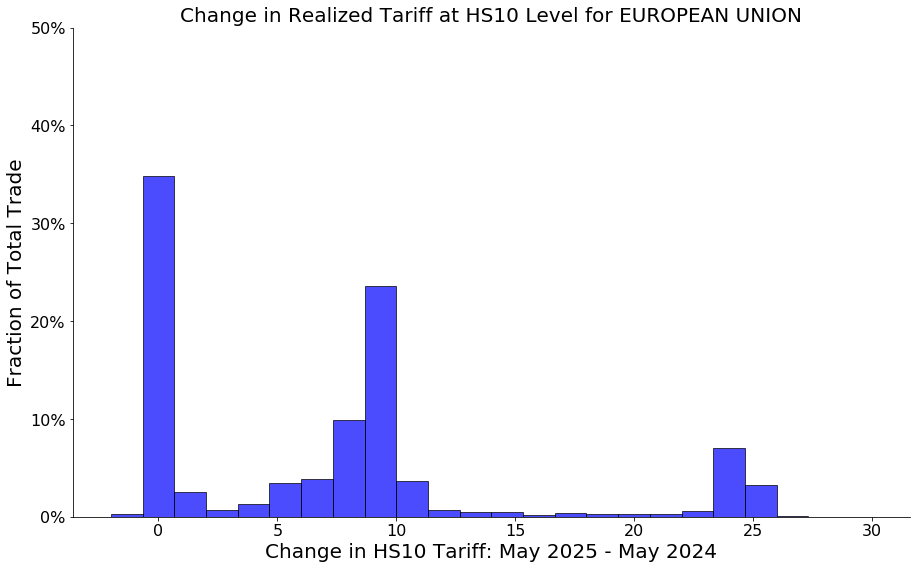

In [37]:
fig, ax = plt.subplots(figsize = (15,9))

bin_edges = np.linspace(-2, 30, 25)  # 50 bins


# Digitize delta_tariff into bins
bin_indices = np.digitize(df["delta_applied_tariff"], bin_edges) - 1

# Sum CON_VAL_MAY in each bin
bin_sums = np.zeros(len(bin_edges) - 1)
for i in range(len(bin_sums)):
    bin_sums[i] = df.loc[bin_indices == i, "CON_VAL_2024"].sum()

# Convert to fraction of total CON_VAL_MAY
fractions = bin_sums / df["CON_VAL_2024"].sum()

ax.bar(bin_edges[:-1], fractions, width=np.diff(bin_edges), align='edge', color='blue', alpha=0.7, edgecolor='black')

ax.set_ylim(top=0.50)

ax.set_ylabel("Fraction of Total Trade", fontsize = 20)

ax.set_ylabel("Fraction of Total Trade", fontsize = 20)

ax.set_xlabel("Change in HS10 Tariff: May 2025 - May 2024", fontsize = 20)

ax.set_title("Change in Realized Tariff at HS10 Level for " + df["CTY_NAME"].iloc[0], fontsize = 20)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

ax.tick_params(axis='x', labelsize=16)  # Change font size of x-axis tick labels
ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

plt.show()

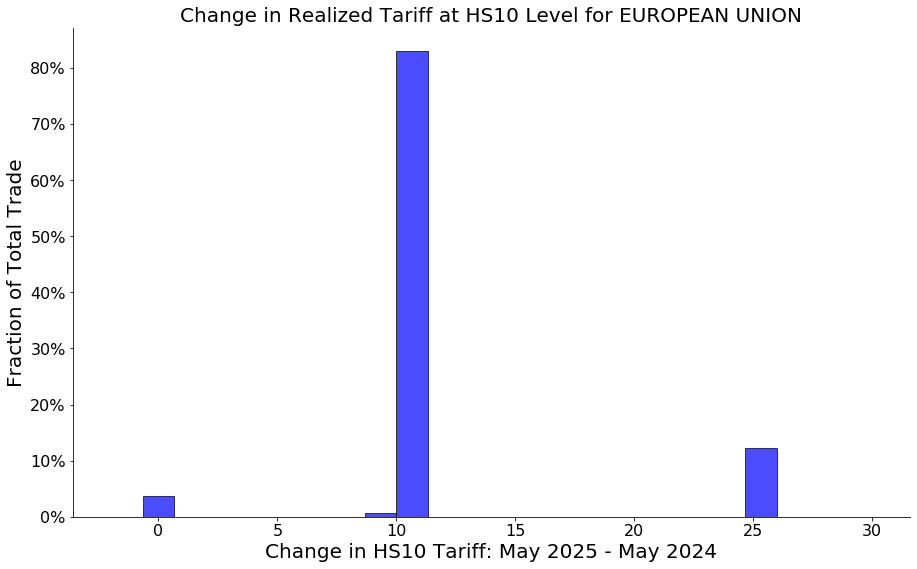

In [41]:
fig, ax = plt.subplots(figsize = (15,9))

bin_edges = np.linspace(-2, 30, 25)  # 50 bins


# Digitize delta_tariff into bins
bin_indices = np.digitize(df["delta_predic_tariff"], bin_edges) - 1

# Sum CON_VAL_MAY in each bin
bin_sums = np.zeros(len(bin_edges) - 1)
for i in range(len(bin_sums)):
    bin_sums[i] = df.loc[bin_indices == i, "CON_VAL_MO"].sum()

# Convert to fraction of total CON_VAL_MAY
fractions = bin_sums / df["CON_VAL_MO"].sum()

ax.bar(bin_edges[:-1], fractions, width=np.diff(bin_edges), align='edge', color='blue', alpha=0.7, edgecolor='black')

# ax.set_ylim(top=0.50)

ax.set_ylabel("Fraction of Total Trade", fontsize = 20)

ax.set_ylabel("Fraction of Total Trade", fontsize = 20)

ax.set_xlabel("Change in HS10 Tariff: May 2025 - May 2024", fontsize = 20)

ax.set_title("Change in Realized Tariff at HS10 Level for " + df["CTY_NAME"].iloc[0], fontsize = 20)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

ax.tick_params(axis='x', labelsize=16)  # Change font size of x-axis tick labels
ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

plt.show()

In [70]:
df_positive_tolerance.sort_values(by=["CON_VAL_MAY"], ascending=False, inplace=True)

df_positive_tolerance.head(50)

c:\ProgramData\Anaconda3\lib\site-packages\pandas\util\_decorators.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return func(*args, **kwargs)


,I_COMMODITY,tariff_MAY,CON_VAL_MAY,tariff,CON_VAL_MO,delta_tariff
3542,9801001028,0.000000,359074871.0,0.000000,104883257.0,0.000000e+00
458,3002140010,0.000000,175196434.0,0.000000,6282742.0,0.000000e+00
612,3004909221,0.000000,142106974.0,0.000000,133143092.0,0.000000e+00
513,3004909234,0.000000,134107750.0,0.000000,3734623.0,0.000000e+00
3056,3004909215,0.006368,116343417.0,0.000000,489778466.0,6.368216e-03
467,3002150011,0.000000,73353249.0,0.000000,12012511.0,0.000000e+00
973,7108121013,0.000000,62813880.0,0.000000,26782353.0,0.000000e+00
3543,9801001030,0.000000,49726286.0,0.000000,59064360.0,0.000000e+00
2470,9021500000,0.001815,48694821.0,0.000000,41675681.0,1.815388e-03
468,3002150091,0.000000,40389701.0,0.000000,319736792.0,0.000000e+00
